<a href="https://colab.research.google.com/github/aswinss949/DSC-DEMO-PROJECT/blob/main/AIML_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training And Evaluating CNN Models On CIFAR-100


# Objective
The goal of this case study is to train, evaluate, and compare CNN architectures for image classification on the CIFAR-100 dataset

In [1]:
# Install libraries
!pip install visualkeras
!pip install graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.5 MB/s eta 0:00:00


# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.utils import plot_model

# Load CIFAR-100 Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)


# Normalize the Data

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-Hot Encode Labels

In [5]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

# Visualize Sample Images

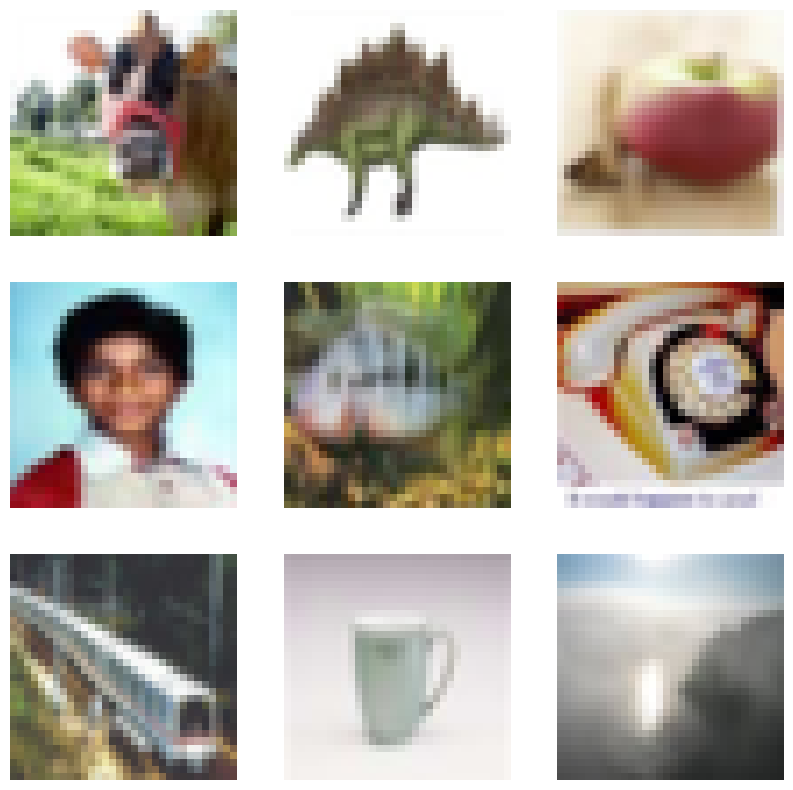

In [6]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.show()

# Build Custom CNN Model

In [7]:
custom_model = Sequential()

# First Convolution Block
custom_model.add(Conv2D(32, (3,3), activation='relu',
                        padding='same',
                        input_shape=(32,32,3)))

custom_model.add(BatchNormalization())

custom_model.add(Conv2D(32, (3,3), activation='relu'))
custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.25))

# Second Convolution Block
custom_model.add(Conv2D(64, (3,3), activation='relu',
                        padding='same'))

custom_model.add(BatchNormalization())

custom_model.add(Conv2D(64, (3,3), activation='relu'))
custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.25))

# Fully Connected Layers
custom_model.add(Flatten())

custom_model.add(Dense(512, activation='relu'))
custom_model.add(Dropout(0.5))

custom_model.add(Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile the Model

In [8]:
custom_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary

In [9]:
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297,412 (4.95 MB)

 Trainable params: 1,297,220 (4.95 MB)

 Non-trainable params: 192 (768.00 B)

# Plot Model Architecture

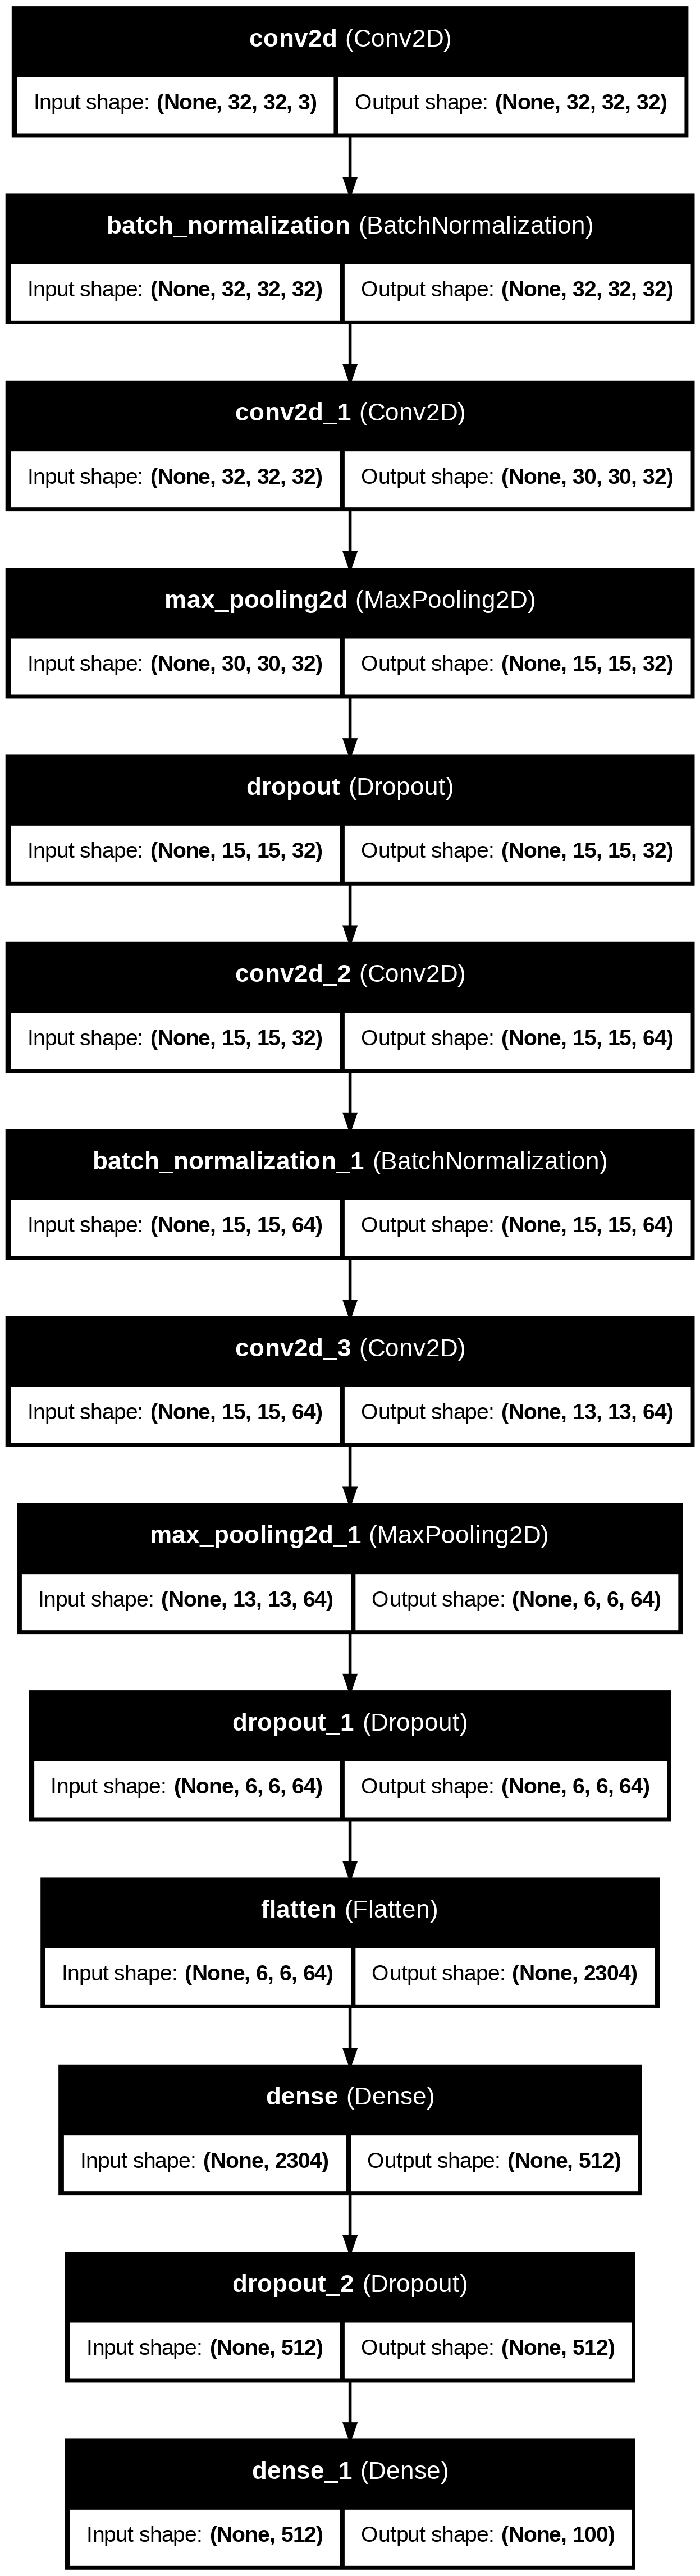

In [10]:
plot_model(
    custom_model,
    show_shapes=True,
    show_layer_names=True
)

# Create Callbacks

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_custom_model.keras',
    save_best_only=True
)

# Train Custom CNN

In [12]:
history_custom = custom_model.fit(
    x_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.0484 - loss: 4.3052 - val_accuracy: 0.1109 - val_loss: 3.8908
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1038 - loss: 3.8509 - val_accuracy: 0.1428 - val_loss: 3.6006
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1479 - loss: 3.5770 - val_accuracy: 0.2047 - val_loss: 3.2893
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1910 - loss: 3.3315 - val_accuracy: 0.2469 - val_loss: 3.0552
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2314 - loss: 3.1143 - val_accuracy: 0.2990 - val_loss: 2.7856
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2682 - loss: 2.9201 - val_accuracy: 0.3152 - val_loss: 2.6962
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3012 - loss: 2.7655 - val_accuracy: 0.3312 - val_loss: 2.6301
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3239 - loss: 2.6388 - val_accuracy: 

# Evaluate Custom CNN

In [14]:
custom_loss, custom_acc = custom_model.evaluate(
    x_test,
    y_test
)

print("Custom CNN Accuracy:", custom_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4592 - loss: 2.0729
Custom CNN Accuracy: 0.459199994802475


# Plot Accuracy & Loss Curves

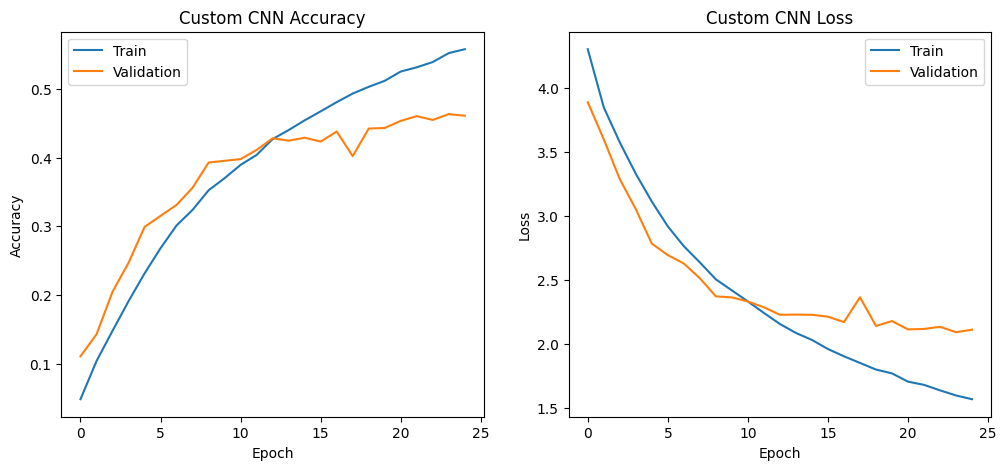

In [15]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history_custom.history['accuracy'])
plt.plot(history_custom.history['val_accuracy'])
plt.title('Custom CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_custom.history['loss'])
plt.plot(history_custom.history['val_loss'])
plt.title('Custom CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

# Build VGG16 Model

In [16]:
base_model = VGG16(
    weights=None,
    include_top=False,
    input_shape=(32,32,3)
)

vgg_model = Sequential()

vgg_model.add(base_model)

vgg_model.add(Flatten())
vgg_model.add(Dense(512, activation='relu'))
vgg_model.add(Dropout(0.5))
vgg_model.add(Dense(100, activation='softmax'))

# Compile VGG16

In [17]:
vgg_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# VGG16 Summary

In [18]:
vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 15,028,644 (57.33 MB)

 Non-trainable params: 0 (0.00 B)

# Plot VGG16 Architecture

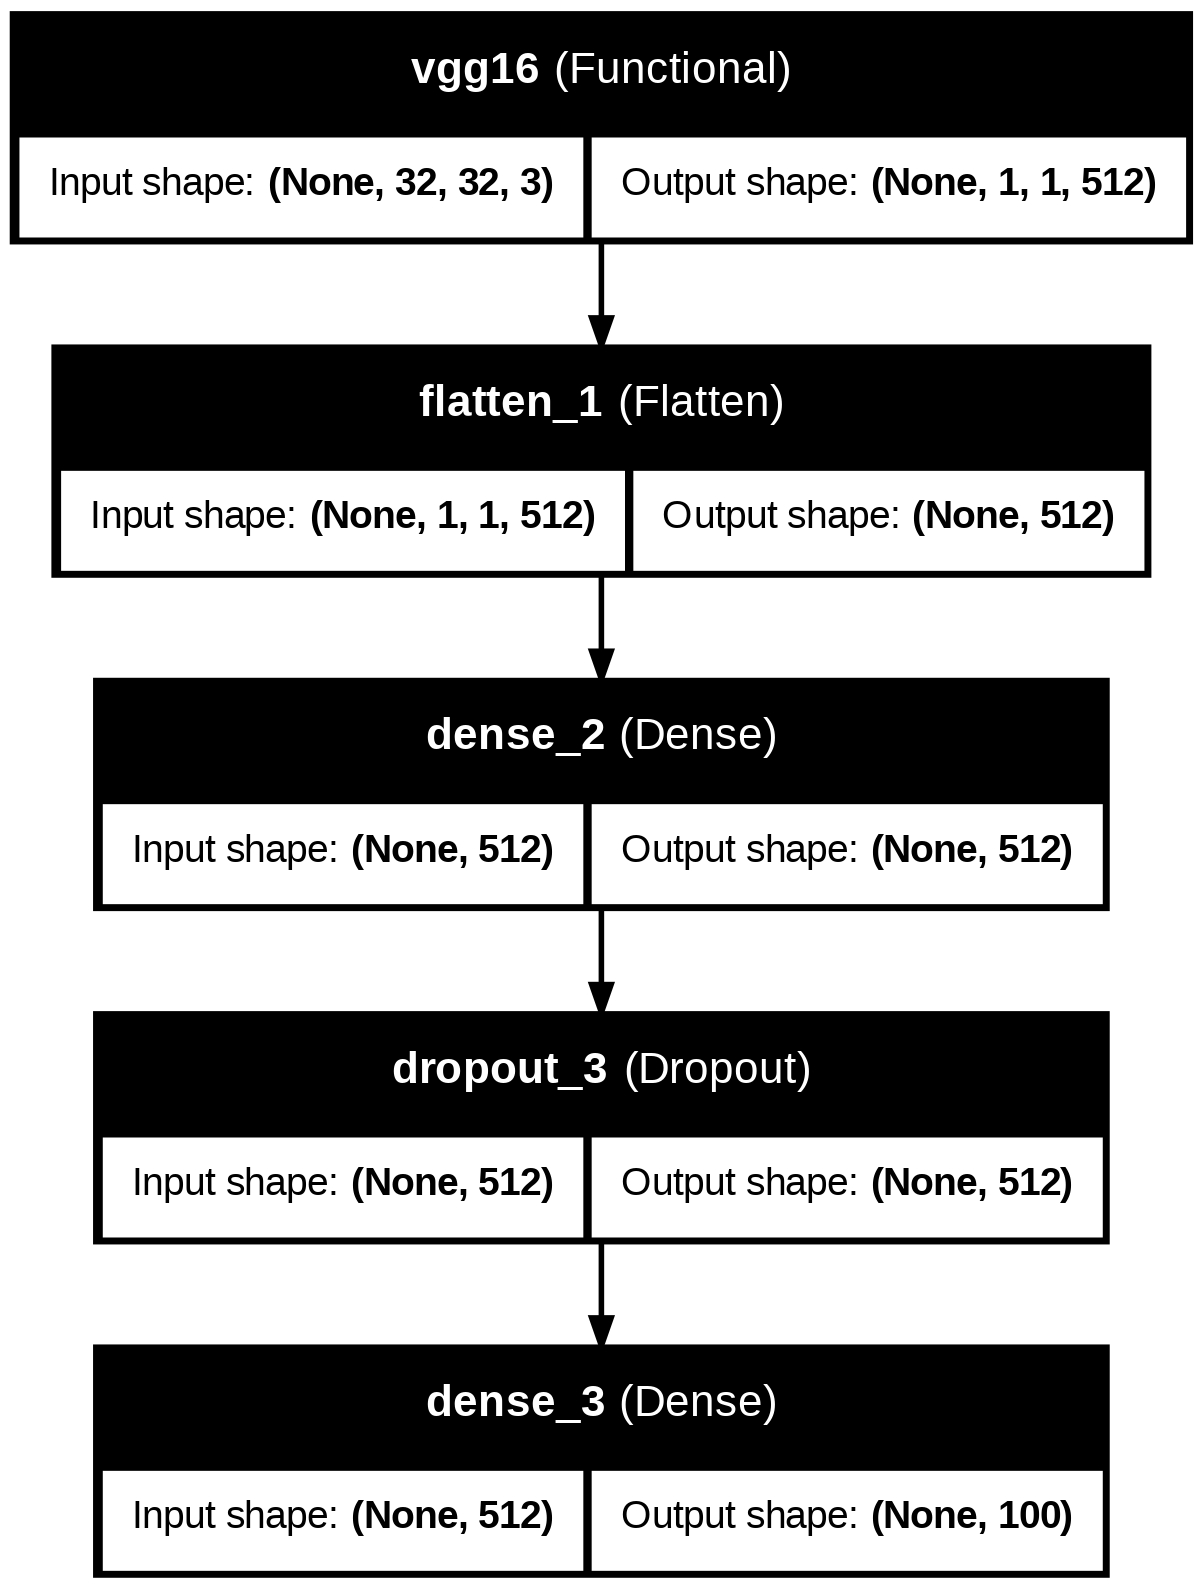

In [19]:
plot_model(
    vgg_model,
    show_shapes=True,
    show_layer_names=True
)

# Train VGG16

In [20]:
history_vgg = vgg_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 73ms/step - accuracy: 0.0086 - loss: 4.6077 - val_accuracy: 0.0086 - val_loss: 4.6063
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.0088 - loss: 4.6056 - val_accuracy: 0.0077 - val_loss: 4.6068
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.0099 - loss: 4.6055 - val_accuracy: 0.0077 - val_loss: 4.6072
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.0097 - loss: 4.6054 - val_accuracy: 0.0077 - val_loss: 4.6076
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.0096 - loss: 4.6054 - val_accuracy: 0.0077 - val_loss: 4.6077


# Evaluate VGG16

In [21]:
vgg_loss, vgg_acc = vgg_model.evaluate(
    x_test,
    y_test
)

print("VGG16 Accuracy:", vgg_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0100 - loss: 4.6053
VGG16 Accuracy: 0.009999999776482582


# Plot VGG16 Curves

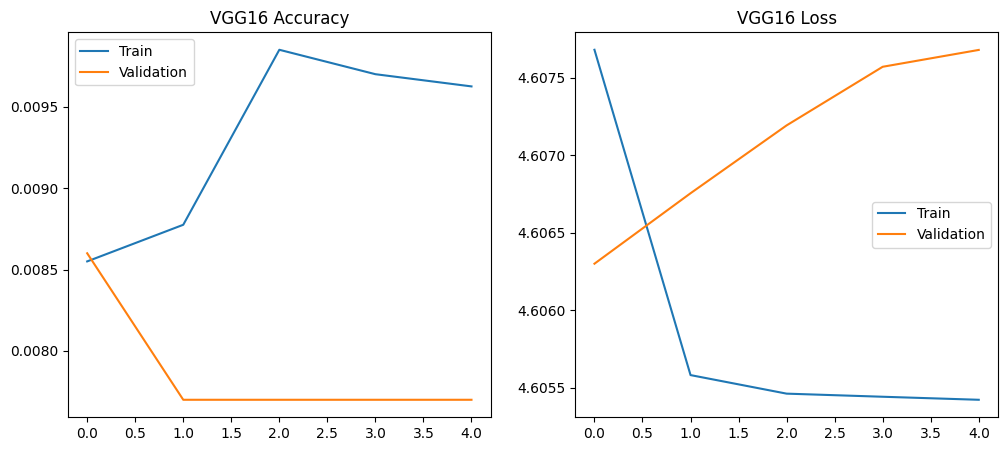

In [22]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('VGG16 Accuracy')
plt.legend(['Train','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title('VGG16 Loss')
plt.legend(['Train','Validation'])

plt.show()

# Compare Final Accuracy

In [23]:
print("========== FINAL COMPARISON ==========")

print(f"Custom CNN Accuracy : {custom_acc:.4f}")
print(f"VGG16 Accuracy      : {vgg_acc:.4f}")

========== FINAL COMPARISON ==========
Custom CNN Accuracy : 0.4592
VGG16 Accuracy      : 0.0100


# Create Accuracy Comparison Table

In [24]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16'],
    'Accuracy': [custom_acc, vgg_acc]
})

print(results)

        Model  Accuracy
0  Custom CNN    0.4592
1       VGG16    0.0100
